# Routing Demo on WOMD Map

This notebook demonstrates the complete lane-level routing workflow on a real Waymo Open Motion Dataset (WOMD) map parsed by `Tactics2D`.

The example covers:

1. Loading a WOMD scenario map.
2. Inspecting candidate lanes and selecting a start/goal pair.
3. Running `Router` on the lane graph.
4. Visualizing the planned route directly on the parsed WOMD map.

The routing module now supports multiple built-in cost presets and a custom callback interface. This demo uses `lanelet2_time`, but the same workflow can switch to `distance`, `time`, `lanelet2_distance`, or `apollo_inspired`, or accept a user-defined `cost_fn(map_, from_lane, to_lane, relation)`.


In [27]:
%matplotlib inline

import importlib.util
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "tactics2d").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np

womd_parser_path = repo_root / "tactics2d" / "dataset_parser" / "parse_womd.py"
womd_spec = importlib.util.spec_from_file_location("routing_womd_parser", womd_parser_path)
womd_module = importlib.util.module_from_spec(womd_spec)
assert womd_spec is not None and womd_spec.loader is not None
womd_spec.loader.exec_module(womd_module)
WOMDParser = womd_module.WOMDParser

from tactics2d.routing import Router

## 1. Load a WOMD scenario map

This example reuses the local WOMD sample shard already used in the existing `womd.ipynb` walkthrough.

In [28]:
parser = WOMDParser()

folder = "../../tactics2d/data/trajectory_sample/WOMD"
file_name = "uncompressed_scenario_validation_interactive_validation_interactive.tfrecord-00000-of-00150"
scenario_id = "234dfbe99b740c80"

map_ = parser.parse_map(scenario_id=scenario_id, file=file_name, folder=folder)
print(f"scenario_id={scenario_id}")
print(f"num_lanes={len(map_.lanes)}")
print(f"boundary={map_.boundary}")

scenario_id=234dfbe99b740c80
num_lanes=664
boundary=(np.float64(11597.0), np.float64(11877.0), np.float64(8180.0), np.float64(8760.0))


## 2. Select start and goal lanes

For a stable and reproducible demo, we use a start lane and a goal lane that have already been verified to produce a valid route on this scenario.

In [29]:
start_lane_id = "00194"
goal_lane_id = "00880"

start_lane = map_.lanes[start_lane_id]
goal_lane = map_.lanes[goal_lane_id]

start = tuple(np.asarray(start_lane.custom_tags["centerline"])[0])
goal = tuple(np.asarray(goal_lane.custom_tags["centerline"])[-1])

print("start_lane_id:", start_lane_id)
print("goal_lane_id:", goal_lane_id)
print("start:", start)
print("goal:", goal)

start_lane_id: 00194
goal_lane_id: 00880
start: (np.float64(11876.475406126598), np.float64(8644.378786460267))
goal: (np.float64(11776.531099531345), np.float64(8264.513297599733))


## 3. Run lane-level routing

The `Router` consumes start and goal **coordinates**. In this demo, we first pick two lanes only to derive stable coordinate samples for a reproducible WOMD example; the actual routing input is still `(start, goal)` in world coordinates.

This notebook uses the `lanelet2_time` preset. Through the unified `Router` interface, `lane_change_penalty` is automatically forwarded to the selected built-in preset (`lane_change_penalty` for `distance/time`, `lane_change_cost` for `lanelet2_*`, and `change_penalty` for `apollo_inspired`). A fully custom `cost_fn` can also be injected without changing the routing pipeline.


In [30]:
router = Router(
    algorithm="dijkstra",
    include_neighbors=True,
    cost_mode="lanelet2_time",
    lane_change_penalty=10.0,
)

route = router.plan(map_, start, goal)

print("matched start lane:", route.start_lane_id)
print("matched goal lane:", route.goal_lane_id)
print("route length:", len(route.lane_ids))
print("route lane ids:")
print(route.lane_ids)
print("total_cost:", route.total_cost)


matched start lane: 00194
matched goal lane: 00880
route length: 24
route lane ids:
['00194', '00552', '00559', '00558', '00530', '00521', '00501', '00272', '00267', '00284', '00675', '00734', '00737', '00748', '00854', '00744', '00743', '00742', '00938', '00933', '00929', '00875', '00879', '00880']
total_cost: 61.91334425250186


## 4. Visualize the route on the WOMD map

We draw a zoomed route-detail view and, separately, a plain map overview using the same scenario. The notebook also saves both rendered figures as PNGs under `tests/runtime/routing/`.

In the detail view, labels such as `3` mean the route order of each lane in the planned sequence.

The highlighted route polyline is `route.path`, which is the concatenated geometric path built from routed lane centerlines. It is a lane-level geometric summary rather than a smoothed driving trajectory, so short connector lanes may still appear as local geometric kinks in the visualization.


saved route figure to: ..\..\tests\runtime\routing\routing_womd_234dfbe99b740c80.png
saved plain map figure to: ..\..\tests\runtime\routing\routing_womd_234dfbe99b740c80_plain.png


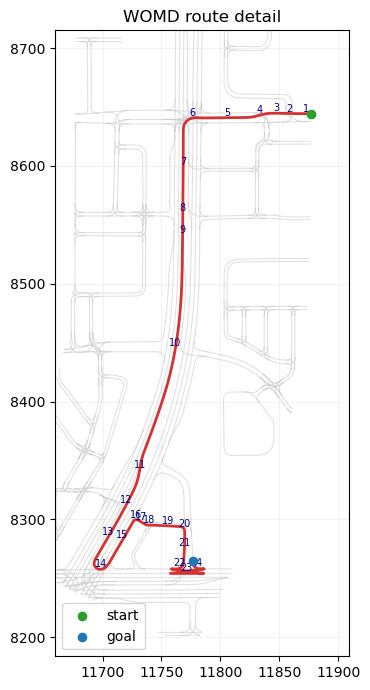

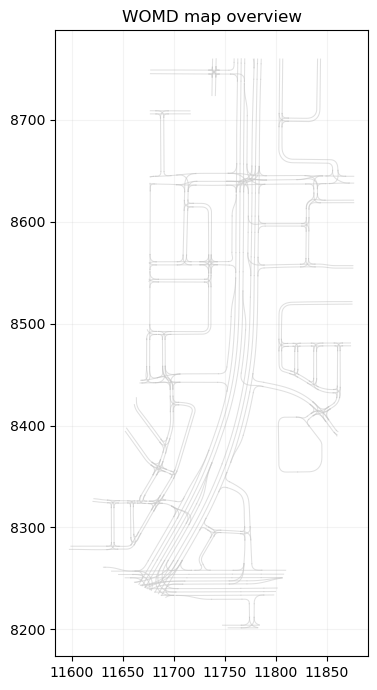

In [31]:
def _plot_map(ax, highlight_lanes=False, show_route=True, show_endpoints=True):
    for lane in map_.lanes.values():
        centerline = lane.custom_tags.get("centerline") if lane.custom_tags is not None else None
        if centerline is None or len(centerline) < 2:
            continue
        centerline = np.asarray(centerline)
        ax.plot(centerline[:, 0], centerline[:, 1], color="0.78", linewidth=0.75, alpha=0.55, zorder=1)

    if show_route:
        if route.path is not None:
            path = np.asarray(route.path)
            ax.plot(path[:, 0], path[:, 1], color="#d62728", linewidth=2.0, alpha=0.95, zorder=4)

            if show_endpoints:
                ax.scatter(path[0, 0], path[0, 1], color="tab:green", s=30, zorder=5)
                ax.scatter(path[-1, 0], path[-1, 1], color="tab:blue", s=30, zorder=5)

            if highlight_lanes:
                for lane_idx, lane_id in enumerate(route.lane_ids):
                    centerline = np.asarray(map_.lanes[lane_id].custom_tags["centerline"])
                    lane_mid = centerline[len(centerline) // 2]
                    path_idx = np.argmin(np.sum((path - lane_mid) ** 2, axis=1))
                    label_x, label_y = path[path_idx]
                    ax.text(
                        label_x,
                        label_y,
                        f"{lane_idx + 1}",
                        fontsize=7,
                        color="navy",
                        ha="center",
                        va="bottom",
                        zorder=5,
                    )

    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)


def _detail_limits():
    if route.path is None:
        return None
    path = np.asarray(route.path)
    x_min, y_min = path.min(axis=0)
    x_max, y_max = path.max(axis=0)
    margin_x = max(20.0, (x_max - x_min) * 0.18)
    margin_y = max(20.0, (y_max - y_min) * 0.18)
    return (x_min - margin_x, x_max + margin_x, y_min - margin_y, y_max + margin_y)


out_dir = Path("../../tests/runtime/routing")
out_dir.mkdir(parents=True, exist_ok=True)
limits = _detail_limits()

fig_route, ax_route = plt.subplots(figsize=(8, 7))
_plot_map(ax_route, highlight_lanes=True, show_route=True, show_endpoints=True)
ax_route.set_title("WOMD route detail")
if limits is not None:
    ax_route.set_xlim(limits[0], limits[1])
    ax_route.set_ylim(limits[2], limits[3])
ax_route.scatter([route.start[0]], [route.start[1]], color="tab:green", s=35, label="start", zorder=6)
ax_route.scatter([route.goal[0]], [route.goal[1]], color="tab:blue", s=35, label="goal", zorder=6)
ax_route.legend(loc="best")
fig_route.tight_layout()
route_out_path = out_dir / f"routing_womd_{scenario_id}.png"
fig_route.savefig(route_out_path, dpi=160, bbox_inches="tight")
print(f"saved route figure to: {route_out_path}")

fig_map, ax_map = plt.subplots(figsize=(8, 7))
_plot_map(ax_map, highlight_lanes=False, show_route=False, show_endpoints=False)
ax_map.set_title("WOMD map overview")
fig_map.tight_layout()
map_out_path = out_dir / f"routing_womd_{scenario_id}_plain.png"
fig_map.savefig(map_out_path, dpi=160, bbox_inches="tight")
print(f"saved plain map figure to: {map_out_path}")

plt.show()





This example demonstrates a full routing workflow on a real parsed WOMD map:

- coordinates are used as the routing input to `Router`,
- `GraphBuilder` converts lanes into a routing graph,
- `Router` plans a lane sequence between start and goal,
- and the final `Route` is visualized as a highlighted polyline on the scenario map.

Beyond this default demo, the same interface can switch among multiple cost presets (`distance`, `time`, `lanelet2_distance`, `lanelet2_time`, `apollo_inspired`) or accept a custom cost function for downstream navigation experiments.

This notebook is intended to serve as the reference demo for the lane-level routing module.
